## About

Here we will attempt to solve a simple 1-d heat equation using finite difference PINNs. 

In [113]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import sys
from numpy import pi
from typing import Tuple, Dict
sys.path.append('../..')

In [114]:
# vlastni import
from src import train, utils
from src import calculus as calc
import src.data.meshed_domain as md
import src.models.mlp_model as mm

In [115]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [116]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [117]:
# constants
ALPHA = 0.1
Lx = 1
T = 0.1
Nx = 100
Nt = 100
dx = Lx / (Nx - 1)
dt = T / (Nt - 1)

In [118]:
mesh_ctx = md.MeshContext2D(
    Nx=Nx,
    Ny=Nt,
    device=device,
    l_bounds=[0, 0],
    u_bounds=[Lx, T]
)

domain = md.MeshDomain2D(mesh_ctx)

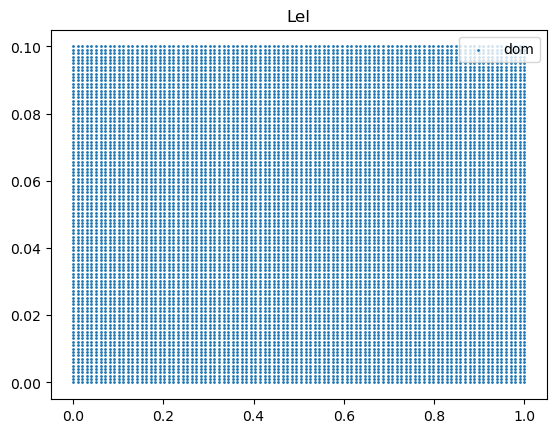

In [119]:
utils.plot_points({"dom": domain.grid}, "Lel")

In [120]:
# compute initial values at the second coordinate lowest boundary, only from the first component
U_INIT = torch.sin(pi * domain.boundaries[2][:, 0:1])

print(U_INIT)

def loss(model: torch.nn.Module, domain: md.MeshDomain2D):
    all_pts = domain.grid.requires_grad_(True)
    u_vals = model(all_pts)
    
    # first compute derivatives on the interior -- i. e. at points captured by mesh_scheme
    u_n_i = u_vals[domain.mesh_scheme[:, 0]]
    u_n_im1 = u_vals[domain.mesh_scheme[:, 3]]
    u_n_ip1 = u_vals[domain.mesh_scheme[:, 4]]
    u_np1_i = u_vals[domain.mesh_scheme[:, 2]]
    
    u_t_f = (u_np1_i - u_n_i) / dt
    u_xx_f = (u_n_ip1 - 2 * u_n_i + u_n_im1) / dx**2
    
    # interior loss. The fact that the point is in the interior is captured by the fact, that we have computed its derivative
    pde_res = u_t_f - ALPHA * u_xx_f
    pde_loss = torch.mean(pde_res**2)
    
    # Now we loss the boundaries
    # Side loss first:
    left_pts = domain.boundaries[0]
    right_pts = domain.boundaries[1]
    side_pts = torch.cat([left_pts, right_pts]).requires_grad_(True)
    u_side = model(side_pts)
    side_loss = torch.mean(u_side**2)
    
    # Next init loss:
    init_pts = domain.boundaries[2].requires_grad_(True)
    u_init = model(init_pts)
    bot_loss = torch.mean((u_init - U_INIT)**2)
    
    return [pde_loss, 100 * side_loss, 100 * bot_loss]



tensor([[ 0.0000e+00],
        [ 3.1728e-02],
        [ 6.3424e-02],
        [ 9.5056e-02],
        [ 1.2659e-01],
        [ 1.5800e-01],
        [ 1.8925e-01],
        [ 2.2031e-01],
        [ 2.5115e-01],
        [ 2.8173e-01],
        [ 3.1203e-01],
        [ 3.4202e-01],
        [ 3.7166e-01],
        [ 4.0093e-01],
        [ 4.2979e-01],
        [ 4.5823e-01],
        [ 4.8620e-01],
        [ 5.1368e-01],
        [ 5.4064e-01],
        [ 5.6706e-01],
        [ 5.9291e-01],
        [ 6.1816e-01],
        [ 6.4279e-01],
        [ 6.6677e-01],
        [ 6.9008e-01],
        [ 7.1269e-01],
        [ 7.3459e-01],
        [ 7.5575e-01],
        [ 7.7615e-01],
        [ 7.9576e-01],
        [ 8.1458e-01],
        [ 8.3257e-01],
        [ 8.4973e-01],
        [ 8.6603e-01],
        [ 8.8145e-01],
        [ 8.9599e-01],
        [ 9.0963e-01],
        [ 9.2235e-01],
        [ 9.3415e-01],
        [ 9.4500e-01],
        [ 9.5490e-01],
        [ 9.6384e-01],
        [ 9.7181e-01],
        [ 9

In [121]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    layer=[32, 32, 32],
    l_bounds=[0, 0],
    u_bounds=[Lx, T]
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_ctx = train.TrainingContext(
    optimizer=optimizer,
    model=model,
    domain=domain,
    epochs=10_000,
    loss_fn=loss,
    resample=False,
    monitor_gradient=True
)

total_loss, component_loss = train.simple_train(train_ctx, epochs_with_lbfgs=500, lbfgs_lr=0.1)

Loss at epoch 1 is: 57.308837890625. 
Loss at epoch 100 is: 1.282067060470581. 
Loss at epoch 200 is: 0.18887275457382202. 
Loss at epoch 300 is: 0.037760552018880844. 
Loss at epoch 400 is: 0.01779666356742382. 
Loss at epoch 500 is: 0.011246194131672382. 
Loss at epoch 600 is: 0.008348571136593819. 
Loss at epoch 700 is: 0.006463703699409962. 
Loss at epoch 800 is: 0.005199895240366459. 
Loss at epoch 900 is: 0.004323067609220743. 
Loss at epoch 1000 is: 0.008285034447908401. 
Loss at epoch 1100 is: 0.010267435573041439. 
Loss at epoch 1200 is: 0.00275301281362772. 
Loss at epoch 1300 is: 0.0024854487273842096. 
Loss at epoch 1400 is: 0.002415506402030587. 
Loss at epoch 1500 is: 0.0020867371931672096. 
Loss at epoch 1600 is: 0.0029456934425979853. 
Loss at epoch 1700 is: 0.0020282368641346693. 
Loss at epoch 1800 is: 0.002362576313316822. 
Loss at epoch 1900 is: 0.018550410866737366. 
Loss at epoch 2000 is: 0.001427469658665359. 
Loss at epoch 2100 is: 0.0013323593884706497. 
Loss a

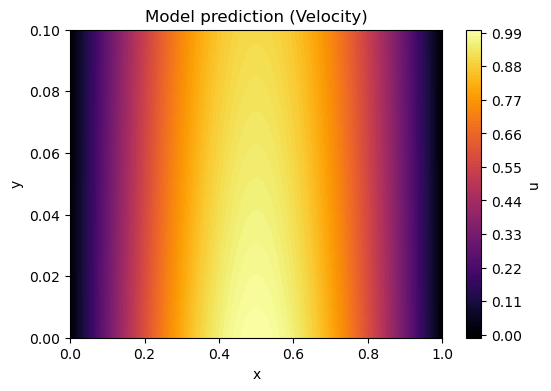

In [123]:
# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=[0, 0],
    u_bounds=[1, 0.1],
    function_names = ['u'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=1,
    patches=[],
    N = 100,
    colour_map='inferno'
)

utils.plot_function_on_2d_cube([model], plot_ctx)

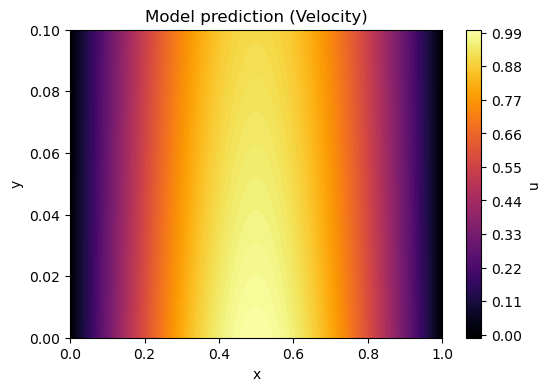

In [124]:
def exact_sol(x):
    return torch.sin(pi * x[:, 0:1]) * torch.exp(-ALPHA * pi**2 * x[:, 1:2])

utils.plot_function_on_2d_cube([exact_sol], plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/FD-PINNs/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


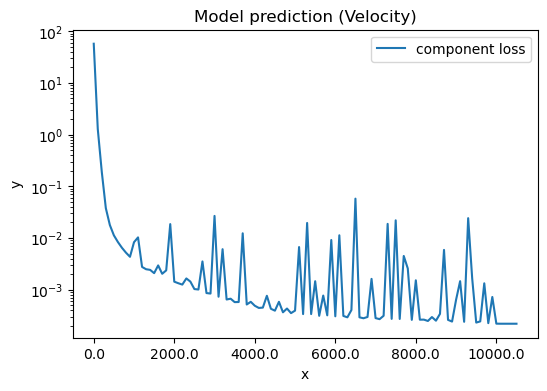

In [125]:
utils.plot_loss_values({"component loss": total_loss}, plot_ctx)